In [2]:
%reset -f
%run setup_notebook.py
from importlib import reload
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import numpy as np
from like3.pixel_table import PixelTable
from like3.sourcelist import SourceModel

from like3 import main as _main; 
source_name = 'Mrk 421'
roi_sources = sm = SourceModel.from_fermi_catalog(
    source_name, #'v40', 
    cone_size=1.0,
    query='significance >= 25',
)
pt = PixelTable('files/kerr/toby_v4.fits', source_model=roi_sources)

if source_name in set(roi_sources.source_names):
    target_name = source_name
else:
    target_name = str(roi_sources.source_names[0])
    print(f" ROI centered on {source_name} ({target_name}) at {sm.selected_source.skydir.to_string()}")

Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries
Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
 ROI centered on Mrk 421 (J1104.4+3812) at 166.125 38.2064


In [25]:
reload(_main)
MultiBandLikelihood = _main.MultiBandLikelihood
mbl = MultiBandLikelihood(pt,sm)
ellipse = mbl.localize(update=True, tolerance=1e-4,)
sigma = ellipse['sigma']
t = mbl.plot_tsmap(npix=15, size=20*sigma, cmap='CMRmap',colorbar=True)#,contour_levels=np.linspace(-5, 0, 6), colorbar=True)

Localizing source J1104.4+3812, tolerance=1.0e-04...
	    step      total     ra        dec       a         b         qual      
	       -      0.0000  166.1114   38.2069
	    0.0001    0.0001  166.1113   38.2069    0.0008    0.0008       0.9
	    0.0000    0.0001  166.1113   38.2069    0.0008    0.0008       0.2
TS change: 0.01


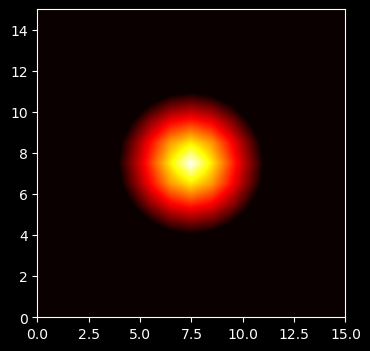

In [26]:
tsmap = t['tsmap']
image = np.sqrt(-tsmap)
ax = None
ra = t['ra']
dec = t['dec']
import matplotlib as mpl
norm2 = mpl.colors.Normalize(vmin=0, vmax=5)
cmap2 = mpl.cm.hot_r
fig, ax = plt.subplots(figsize=(4,4)) if ax is None else (ax.figure, ax)
nx,ny = image.shape
ims = ax.imshow(image, origin='lower', 
    extent=(0,nx,0,ny),
    cmap=cmap2, norm=norm2,
    interpolation='bilinear')

ValueError: Number of pixels must be divisible by 12

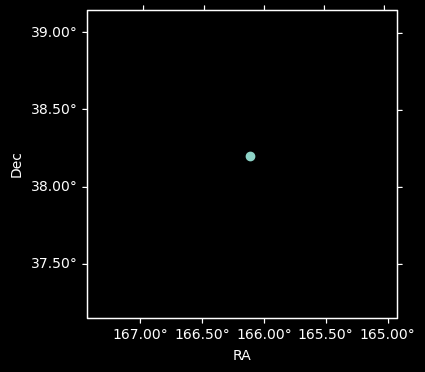

In [40]:
import utilities.skymaps as skymaps
reload(skymaps)
ZEAfigure = skymaps.ZEAfigure
center = sm.selected_source.skydir
zea = ZEAfigure(center, size=2, figsize=(4,4), frame='ICRS')
zea.scatter(center)
ny, nx = zea.array_shape
pixel_y, pixel_x = np.indices((ny, nx))
pixel_skycoords = zea.pixel_to_world(pixel_x, pixel_y)
sep = pixel_skycoords.separation(center).deg
z = np.exp(-sep / sigma  )
zea.imshow(z, cmap='CMRmap',);

In [ ]:
fig, ax = plt.subplots(figsize=figsize) if ax is None else (ax.figure, ax)

if contour_levels is None:
    contour_levels = np.linspace(float(np.nanmin(scaled_tsmap)), float(np.nanmax(scaled_tsmap)), 6)

contour = ax.contourf(ra, dec, tsmap, cmap=cmap, 
        levels = np.linspace(float(np.nanmin(scaled_tsmap)), float(np.nanmax(scaled_tsmap)), 26))

ax.contour(ra, dec, tsmap, levels=contour_levels, colors='white', linewidths=0.8)
ax.clabel(contour)#, inline=True, fontsize=8, fmt='%.1f')

if show_source:
    ax.plot(center.ra.deg, center.dec.deg, marker='+', color='white', markersize=10, mew=1.5)

if show_peak:
    peak_index = np.unravel_index(np.nanargmax(tsmap), tsmap.shape)
    ax.plot(ra[peak_index], dec[peak_index], marker='x', color='black', markersize=7, mew=1.5)

ax.set(
    xlabel='RA (deg)',
    ylabel='Dec (deg)',
    title=f'{source.name} TS map',
)
ax.invert_xaxis()
ax.set_box_aspect(1)

if colorbar:
    fig.colorbar(contour, ax=ax,)# label=r'$\sigma (\sqrt{TS_{\max}-TS})$')


array([[-25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        ],
       [-25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        ],
       [-25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        ],
       [-25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        , -25.        ,
        -25.        , -25.        , -25.        ],
       [-25.        , -25.  